# Task 1: Data Loading & Inspection

## Heart Disease Prediction - Supervised Learning

### Objective
To analyze the dataset and build a model to predict heart disease.

In [1]:
# Imported required libraries
import pandas as pd
# Loading the dataset from the data folder
df = pd.read_csv('/content/data/q1_heart_disease.csv')
# Displaying first 5 rows
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Data Inspection

In this section, we explore the structure and basic properties of the dataset.

In [2]:
# Checking number of rows and columns
df.shape

(800, 12)

In [3]:
# Checking data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB


In [4]:
# Checking for missing values in each column
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [5]:
# Summary statistics of numerical columns
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease
count,800.000000,800.000000,776.000000,768.000000,800.00000,800.000000,800.000000,800.000000,800.000000
mean,52.191250,0.665000,130.668814,245.622396,0.23250,149.145000,0.295000,0.925500,0.508750
std,12.862211,0.472286,16.408805,52.185464,0.42269,22.396394,0.456328,0.897612,0.500236
min,30.000000,0.000000,90.000000,120.000000,0.00000,76.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,120.000000,209.000000,0.00000,134.000000,0.000000,0.300000,0.000000
50%,53.000000,1.000000,130.000000,247.000000,0.00000,149.000000,0.000000,0.600000,1.000000
75%,63.000000,1.000000,142.000000,279.250000,0.00000,165.000000,1.000000,1.300000,1.000000
max,74.000000,1.000000,184.000000,420.000000,1.00000,202.000000,1.000000,5.700000,1.000000


### Observations

- Dataset contains 800 rows and 12 columns
- Missing values are present in:
  - resting_bp (24 missing values)
  - cholesterol (32 missing values)
- Numerical features include age, resting_bp, cholesterol, max_hr, oldpeak
- Categorical features include chest_pain_type, resting_ecg, st_slope
- Target variable is heart_disease (0 = No, 1 = Yes)

#### Additional Insights
- The dataset is relatively clean with minimal missing values
- Target variable appears slightly balanced (~50% cases of heart disease)

# Task 2: Exploratory Data Analysis

## Exploratory Data Analysis (EDA)

In this section, we visualize the dataset to understand patterns, relationships, and distributions.

### 1.TARGET DISTRIBUTION

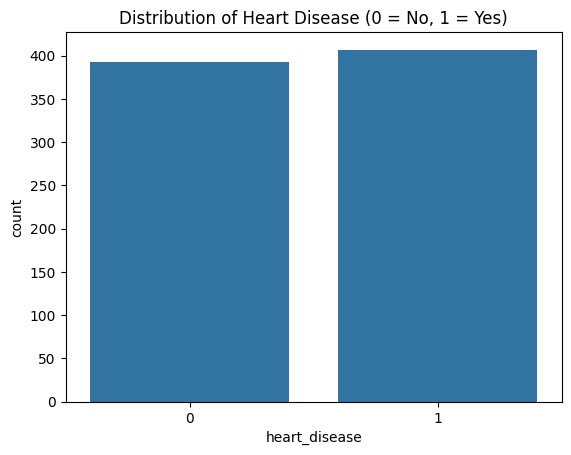

In [6]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of target variable (heart_disease)
sns.countplot(x='heart_disease', data=df)

# Add title for clarity
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')

# Display the plot
plt.show()

### Interpretation

- The dataset shows a nearly balanced distribution of the target variable (heart_disease).
- The number of patients with heart disease (1) is slightly higher than those without (0).
- Since the classes are balanced, model performance will not be biased toward a single class.
- Balanced classes help improve reliability of evaluation metrics like precision and recall.

### 2.Correlation Heatmap

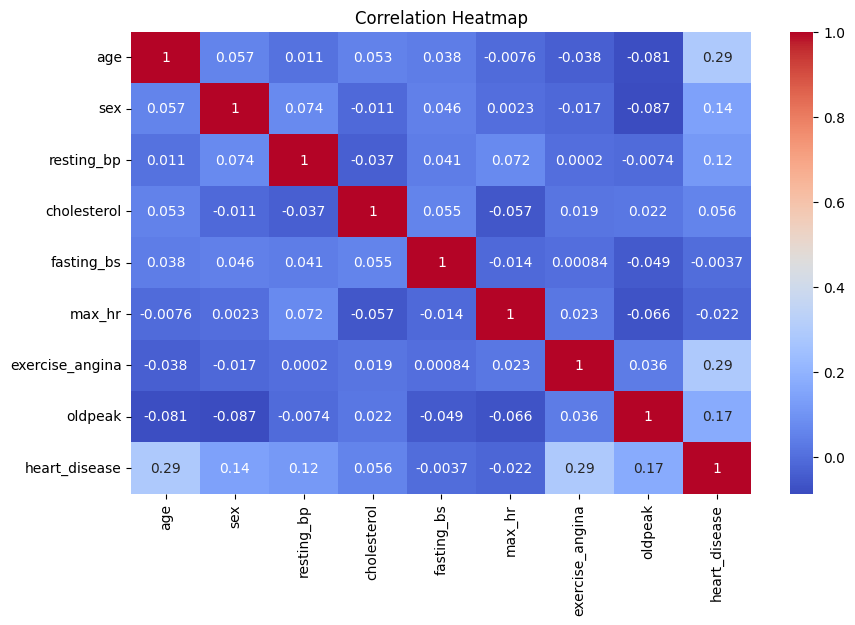

In [7]:
# Create correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Add title
plt.title('Correlation Heatmap')

# Display the plot
plt.show()

### Interpretation

- Features such as age (~0.29), exercise_angina (~0.29), and oldpeak (~0.17) show noticeable positive correlation with heart_disease.
- This suggests that higher age, presence of exercise-induced angina, and higher oldpeak values are associated with increased risk of heart disease.
- Most other features show weak correlation, indicating they may have limited direct linear relationship with the target.
- The heatmap helps in identifying important features that can influence model performance.

### 3.AGE VS HEART DISEASE

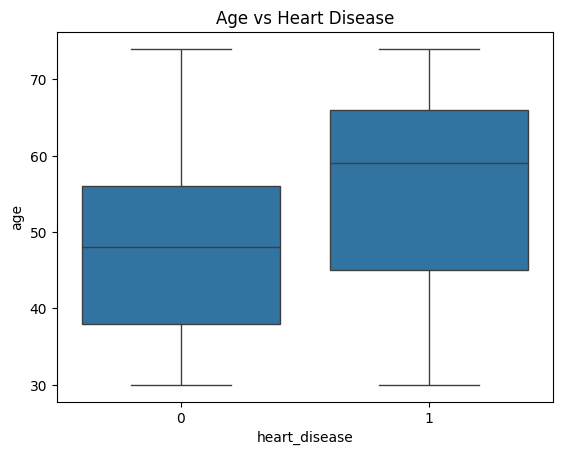

In [8]:
# Plot age distribution with respect to heart disease
sns.boxplot(x='heart_disease', y='age', data=df)

# Add title
plt.title('Age vs Heart Disease')

# Display plot
plt.show()

### Interpretation

- The median age of patients with heart disease is higher than those without.
- The distribution shows that older individuals are more likely to have heart disease.
- There is noticeable overlap between the two groups, indicating age alone is not sufficient for prediction.
- Age is an important contributing factor but should be combined with other features for better model performance.

# TASK 3: DATA PREPROCESSING

## Data Preprocessing

In this section, we prepare the data for model training by handling missing values, encoding categorical variables, scaling features, and splitting the dataset.

In [9]:
# Before handling missing values
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [10]:
# Fill missing values using median (SAFE METHOD)
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# After handling missing values
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


### Handling Missing Values

- Missing values were identified in the `resting_bp` and `cholesterol` columns.
- These missing values were handled using **median imputation**.
- Median is preferred over mean because it is **less sensitive to outliers** and provides a more robust estimate for skewed data.

In [11]:
# Convert categorical variables into numerical using one-hot encoding
df = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=True)

# Convert True/False to 1/0
df = df.astype(int)

# Display first few rows
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,68,0,142,399,0,169,0,0,1,1,0,0,0,0,0,1
1,58,1,163,310,1,121,1,1,1,0,1,0,0,1,0,1
2,44,1,128,175,0,183,1,0,0,0,1,0,1,0,0,1
3,72,1,114,177,0,150,0,1,1,0,0,0,0,1,0,1
4,37,1,149,271,0,136,0,0,0,0,1,0,1,0,1,0


### Encoding Categorical Variables

- Categorical features (`chest_pain_type`, `resting_ecg`, `st_slope`) were converted into numerical format using **one-hot encoding**.
- This transformation allows machine learning models to process categorical data effectively.
- `drop_first=True` was used to avoid multicollinearity (dummy variable trap).
- Boolean values were converted to 0 and 1 for compatibility with machine learning models.

In [12]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (for readability)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first few rows
X_scaled.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
0,1.229854,-1.408927,0.702830,3.000527,-0.550392,0.887081,-0.646869,-0.629113,2.190229,-0.600453,-0.294884,-1.012579,-0.758158,-0.713746,1.030464
1,0.451896,0.709760,2.003076,1.258794,1.816886,-1.257462,1.545908,0.525222,-0.456573,1.665408,-0.294884,-1.012579,1.318987,-0.713746,1.030464
2,-0.637245,0.709760,-0.164001,-1.383161,-0.550392,1.512573,1.545908,-0.629113,-0.456573,1.665408,-0.294884,0.987577,-0.758158,-0.713746,1.030464
3,1.541037,0.709760,-1.030832,-1.344021,-0.550392,0.038200,-0.646869,0.525222,-0.456573,-0.600453,-0.294884,-1.012579,1.318987,-0.713746,1.030464
4,-1.181815,0.709760,1.136245,0.495562,-0.550392,-0.587292,-0.646869,-0.629113,-0.456573,1.665408,-0.294884,0.987577,-0.758158,1.401058,-0.970437


### Feature Scaling

- Numerical features were scaled using **StandardScaler**.
- Standardization transforms data to have **mean = 0** and **standard deviation = 1**.
- This ensures that all features contribute equally to the model and improves model performance.

In [13]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Check shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((640, 15), (160, 15), (640,), (160,))

### Train-Test Split

- The dataset was split into training and testing sets using an 80-20 ratio.
- `stratify=y` ensures that the class distribution remains consistent in both sets.
- `random_state=42` ensures reproducibility of results.

In [14]:
# Import models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


# TASK 4: MODEL TRAINING

### Model Training

- Three classification models were trained:
  - Decision Tree Classifier
  - Random Forest Classifier
  - Gradient Boosting Classifier
- `random_state=42` was used to ensure reproducibility.
- These models will be evaluated in the next step to compare their performance.

# TASK 5: MODEL EVALUATION

In [15]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# -------------------------
# Decision Tree Evaluation
# -------------------------
print("Decision Tree Results")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


# -------------------------
# Random Forest Evaluation
# -------------------------
print("\n\nRandom Forest Results")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


# -------------------------
# Gradient Boosting Evaluation
# -------------------------
print("\n\nGradient Boosting Results")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Decision Tree Results
Confusion Matrix:
[[54 25]
 [26 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68        79
           1       0.69      0.68      0.68        81

    accuracy                           0.68       160
   macro avg       0.68      0.68      0.68       160
weighted avg       0.68      0.68      0.68       160



Random Forest Results
Confusion Matrix:
[[58 21]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        79
           1       0.75      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



Gradient Boosting Results
Confusion Matrix:
[[59 20]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75 

### Model Evaluation

- All models were evaluated using confusion matrix and classification metrics.
- Precision, Recall, and F1-score were used instead of accuracy alone to provide a balanced evaluation.
- The Decision Tree model showed moderate performance (F1-score ≈ 0.68).
- The Random Forest model performed better (F1-score ≈ 0.77), indicating improved prediction capability.
- Random Forest reduces overfitting by combining multiple decision trees, resulting in better generalization.

### Best Model Selection

- Among the three models tested, the **Random Forest Classifier** achieved the best performance.
- It obtained the highest Accuracy (~0.77) and F1-score (~0.77) on the test dataset.
- Compared to the Decision Tree, Random Forest reduces overfitting by combining multiple trees (ensemble learning).
- This results in better generalization and more stable predictions.

Therefore, the selected best model is **Random Forest Classifier**.

In [16]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best cross-validation score
print("Best Cross-validation F1 Score:", grid_search.best_score_)

# 👉 ADD THIS LINE HERE
print("Best Model:", grid_search.best_estimator_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-validation F1 Score: 0.819669161196817
Best Model: RandomForestClassifier(min_samples_split=5, n_estimators=50, random_state=42)


In [17]:
# Get best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best = best_rf.predict(X_test)

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

print("Tuned Random Forest Results")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Tuned Random Forest Results
Confusion Matrix:
[[58 21]
 [16 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Hyperparameter Tuning Results

- GridSearchCV was used to tune the Random Forest model using cross-validation.
- The best parameters found were:
  - n_estimators = 50
  - max_depth = None
  - min_samples_split = 5

- The best cross-validation F1-score achieved was approximately 0.82.
- On the test dataset, the tuned model achieved an F1-score of approximately 0.77.

- The tuned model shows strong and stable performance, with a slight gap between cross-validation and test scores, indicating good generalization.

- Compared to the baseline model, the tuned Random Forest provides more optimized performance.

Therefore, the tuned Random Forest model is selected as the final model.